In [1]:
import textwrap

import faceted
import numpy as np
import wandb
import matplotlib as mpl
import pandas as pd
import xarray as xr

from matplotlib.lines import Line2D

import plotting
import utils

In [2]:
api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/spencerc/.netrc.


In [3]:
def wandb_id_from_name(name):
    api = wandb.Api()
    runs = api.runs("ai2cm/ace-shield", filters={"display_name": {"$regex": name}})
    completed = [run for run in runs if run.state == "finished"]
    return completed[-1]

SHIELD_RUNS = {
    f"SHiELD-4xCO2-ic_{ic}": wandb_id_from_name(f"shield-data-only-evaluator-abrupt4xCO2-ic-{ic:04d}") for ic in range(1, 37)
}

In [4]:
Lv = 2.5e6  # J/kg
SECONDS_PER_DAY = 86400

VARIABLE_NAMES = [
    "PRATEsfc",
    "LHTFLsfc",
    "SHTFLsfc",
    "surface_temperature",
    "air_temperature_0",
    "air_temperature_1",
    "air_temperature_2",
    "air_temperature_3",
    "air_temperature_4",
    "air_temperature_5",
    "air_temperature_6",
    "air_temperature_7",
    "ULWRFtoa",
    "net_energy_flux_toa_into_atmosphere",
    "USWRFtoa",
    "DSWRFsfc",
    "USWRFsfc",
    "DLWRFsfc",
    "ULWRFsfc",
    "total_energy_ace2_path",
    "net_energy_flux_sfc_into_atmosphere",
    "net_energy_flux_into_atmospheric_column",
    "implied_tendency_of_total_energy_ace2_path_due_to_advection",
    "total_water_path",
]
METRIC_NAMES = [f"inference/mean/weighted_mean_gen/{var}" for var in VARIABLE_NAMES]
BIAS_NAMES = [f"inference/mean/weighted_bias/{var}" for var in VARIABLE_NAMES]
TARGET_NAMES = [f"inference/mean/weighted_mean_target/{var}" for var in VARIABLE_NAMES]
UNITS = {
    "PRATEsfc": "mm/day",
    "LHTFLsfc": "W/m^2",
    "SHTFLsfc": "W/m^2",
    "surface_temperature": "K",
    "air_temperature_0": "K",
    "air_temperature_1": "K",
    "air_temperature_2": "K",
    "air_temperature_3": "K",
    "air_temperature_4": "K",
    "air_temperature_5": "K",
    "air_temperature_6": "K",
    "air_temperature_7": "K",
    "ULWRFtoa": "W/m^2",
    "net_energy_flux_toa_into_atmosphere": "W/m^2",
    "USWRFtoa": "W/m^2",
    "DSWRFsfc": "W/m^2",
    "USWRFsfc": "W/m^2",
    "DLWRFsfc": "W/m^2",
    "ULWRFsfc": "W/m^2",
    "total_energy_ace2_path": "J/m^2",
    "net_energy_flux_sfc_into_atmosphere": "W/m^2",
    "net_energy_flux_into_atmospheric_column": "W/m^2",
    "implied_tendency_of_total_energy_ace2_path_due_to_advection": "W/m^2",
    "energy budget imbalance\n(energy tendency minus flux into atmos)": "W/m^2",
    "total_water_path": "mm",
    "imposed_heating": "W/m^2",
    "evaporation": "mm/day",
}

In [5]:
TEMPLATE = "2026-09-09-{model}-abrupt-4xCO2-ensemble-evaluator"

# these runs did a 36-member ensemble in a single run so already have
# ensemble-mean statistics
ACE_RUN_IDS = {
    "ACE2-SOM baseline 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="published-baseline-rs3")),
    "no-random-co2 non-energy-conserving rs0 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-rs0")),
    "no-random-co2 non-energy-conserving rs1 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-rs1")),
    "no-random-co2 energy-conserving rs0 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs0")),
    "no-random-co2 energy-conserving rs1 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs1")),
    "full non-energy-conserving rs0 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-rs0")),
    "full non-energy-conserving rs1 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-rs1")),
    "full energy-conserving rs0 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0")),
    "full energy-conserving rs1 4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1")),
}


In [6]:
COLORS = {
    "SHiELD 4xCO2": "k",
    "SHiELD 1xCO2": "k",
    "ACE2-SOM baseline 4xCO2": "C3",
    "no-random-co2 non-energy-conserving rs0 4xCO2": "C1",
    "no-random-co2 non-energy-conserving rs1 4xCO2": "C1",
    "no-random-co2 energy-conserving rs0 4xCO2": "C2",
    "no-random-co2 energy-conserving rs1 4xCO2": "C2",
    "full non-energy-conserving rs0 4xCO2": "C5",
    "full non-energy-conserving rs1 4xCO2": "C5",
    "full energy-conserving rs0 4xCO2": "C4",
    "full energy-conserving rs1 4xCO2": "C4",
}
LINESTYLES = {"SHiELD 1xCO2": "--"}

In [7]:
ACE_RUNS = {}
for name, id in ACE_RUN_IDS.items():
    ACE_RUNS[name] = api.run(id)

In [8]:
def load_metrics_from_wandb(run, keys, offset_time=1):
    history = pd.DataFrame(run.scan_history(keys=keys))
    ds = xr.Dataset.from_dataframe(history)
    ds = ds.rename({"index": "time"})
    ds["time"] = ((ds.time + offset_time) / 4).assign_attrs(units="days since init")
    ds = ds.assign_coords(time=ds.time)
    return ds.rename({s: s.rsplit('/', 1)[-1] for s in ds.data_vars})

In [9]:
# Initialize an empty dictionary to store the data
ds_shield = []

# Loop through each model and case to extract the metric data
for name, run in SHIELD_RUNS.items():
    ds = load_metrics_from_wandb(run, METRIC_NAMES)
    ds = ds.assign_coords(initial_condition=name[-4:])
    ds_shield.append(ds)
ds_shield = xr.concat(ds_shield, dim="ic")
ds_shield["PRATEsfc"] = (ds_shield["PRATEsfc"] * SECONDS_PER_DAY).assign_attrs(units="mm/day")
ds_shield_mean = ds_shield.mean("ic")

In [10]:
ds_ace_4xCO2 = []

for name, run in ACE_RUNS.items():
    ds = load_metrics_from_wandb(run, METRIC_NAMES)
    ds = ds.assign_coords(model=name)
    ds_ace_4xCO2.append(ds)
ds_ace_4xCO2 = xr.concat(ds_ace_4xCO2, dim="model")
ds_ace_4xCO2["PRATEsfc"] = (ds_ace_4xCO2["PRATEsfc"] * SECONDS_PER_DAY).assign_attrs(units="mm/day")

run = ACE_RUNS["no-random-co2 non-energy-conserving rs0 4xCO2"]
ds_shield_1xCO2 = load_metrics_from_wandb(run, TARGET_NAMES)
ds_shield_1xCO2 = ds_shield_1xCO2.assign_coords(model="SHiELD 1xCO2")
ds_shield_1xCO2["PRATEsfc"] = (ds_shield_1xCO2["PRATEsfc"] * SECONDS_PER_DAY).assign_attrs(units="mm/day")

In [11]:
ds = xr.concat(
    [
        ds_shield_1xCO2,
        ds_shield_mean.assign_coords(model='SHiELD 4xCO2'),
        ds_ace_4xCO2,
    ],
    dim="model",
    join='inner'
)
ds['evaporation'] = ds['LHTFLsfc'] / Lv * SECONDS_PER_DAY

for name in ds:
    if name in UNITS:
        ds[name].attrs['units'] = UNITS[name]


ds["frozen_precipitation_energy_flux"] = (
    ds.net_energy_flux_sfc_into_atmosphere
    + ds.DLWRFsfc
    + ds.DSWRFsfc
    - ds.ULWRFsfc
    - ds.USWRFsfc
    - ds.LHTFLsfc
    - ds.SHTFLsfc
)
ds_daily = ds.coarsen(time=4, boundary="trim").mean()

In [20]:
def function_to_fit(x, initial_value, equilibrium_value, timescale):
    return equilibrium_value + (initial_value - equilibrium_value) * np.exp(-x / timescale)


def evaluate(fit, time):
    initial_value = fit.curvefit_coefficients.sel(param="initial_value")
    equilibrium_value = fit.curvefit_coefficients.sel(param="equilibrium_value")
    timescale = fit.curvefit_coefficients.sel(param="timescale")
    return function_to_fit(time, initial_value, equilibrium_value, timescale)

In [28]:
ds_daily_zeroed_time = ds_daily.assign_coords(time=ds_daily.time - ds_daily.time.isel(time=0))

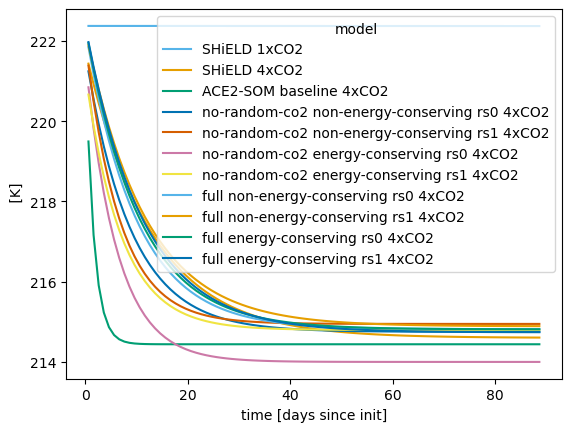

In [22]:
evaluate(ds_daily.air_temperature_0.curvefit("time", function_to_fit), ds_daily.time).plot(hue="model")

/tmp/ipykernel_19844/1276208275.py:2: RuntimeWarning: overflow encountered in exp
  return equilibrium_value + (initial_value - equilibrium_value) * np.exp(-x / timescale)


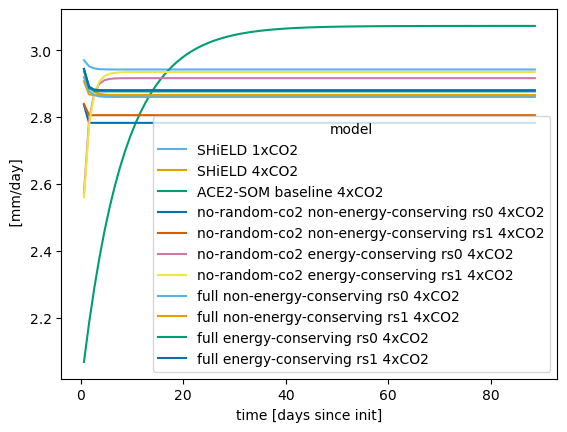

In [23]:
evaluate(ds_daily.PRATEsfc.curvefit("time", function_to_fit), ds_daily.time).plot(hue="model")

In [17]:
ds_daily.air_temperature_0.curvefit("time", function_to_fit).curvefit_coefficients.sel(param="timescale").to_dataframe()

,param,curvefit_coefficients
model,,
SHiELD 1xCO2,timescale,36105.175684
SHiELD 4xCO2,timescale,12.845985
ACE2-SOM baseline 4xCO2,timescale,1.617882
no-random-co2 non-energy-conserving rs0 4xCO2,timescale,8.818567
no-random-co2 non-energy-conserving rs1 4xCO2,timescale,6.706414
no-random-co2 energy-conserving rs0 4xCO2,timescale,6.186662
no-random-co2 energy-conserving rs1 4xCO2,timescale,6.999023
full non-energy-conserving rs0 4xCO2,timescale,9.903902
full non-energy-conserving rs1 4xCO2,timescale,11.672781


In [32]:
ds_daily.ULWRFtoa.curvefit("time", function_to_fit).curvefit_coefficients.to_dataframe()

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/xarray/computation/fit.py:484: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, p0=p0_, bounds=(lb, ub), **kwargs)


curvefit_coefficients
model                                         param                                   
SHiELD 1xCO2                                  initial_value                 241.420463
                                              equilibrium_value             241.526569
                                              timescale                      39.573597
SHiELD 4xCO2                                  initial_value                 237.633468
                                              equilibrium_value             235.104137
                                              timescale                       3.823138
ACE2-SOM baseline 4xCO2                       initial_value                 236.306072
                                              equilibrium_value             240.549072
                                              timescale                      12.311432
no-random-co2 non-energy-conserving rs0 4xCO2 initial_value                 237.258910
                                              equilibrium_value             240.158731
                                              timescale                      37.009551
no-random-co2 non-energy-conserving rs1 4xCO2 initial_value                 236.847431
                                              equilibrium_value             240.143065
                                              timescale                      47.994589
no-random-co2 energy-conserving rs0 4xCO2     initial_value                 243.757810
                                              equilibrium_value             235.533947
                                              timescale                       0.437931
no-random-co2 energy-conserving rs1 4xCO2     initial_value                 243.691402
                                              equilibrium_value             235.956699
                                              timescale                       0.019264
full non-energy-conserving rs0 4xCO2          initial_value                 235.654148
                                              equilibrium_value             235.650362
                                              timescale                     -16.904500
full non-energy-conserving rs1 4xCO2          initial_value                 237.211602
                                              equilibrium_value             235.869250
                                              timescale                       3.493133
full energy-conserving rs0 4xCO2              initial_value                 237.192001
                                              equilibrium_value             235.605542
                                              timescale                       3.397778
full energy-conserving rs1 4xCO2              initial_value                 237.244142
                                              equilibrium_value             235.573026
                                              timescale                       4.824449

In [33]:
ds_daily_zeroed_time.ULWRFtoa.curvefit("time", function_to_fit).curvefit_coefficients.to_dataframe()

/tmp/ipykernel_19844/1276208275.py:2: RuntimeWarning: overflow encountered in exp
  return equilibrium_value + (initial_value - equilibrium_value) * np.exp(-x / timescale)
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/xarray/computation/fit.py:484: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x, y, p0=p0_, bounds=(lb, ub), **kwargs)


curvefit_coefficients
model                                         param                                   
SHiELD 1xCO2                                  initial_value                 241.422140
                                              equilibrium_value             241.526601
                                              timescale                      39.605850
SHiELD 4xCO2                                  initial_value                 237.252006
                                              equilibrium_value             235.104137
                                              timescale                       3.823146
ACE2-SOM baseline 4xCO2                       initial_value                 236.516095
                                              equilibrium_value             240.549072
                                              timescale                      12.311432
no-random-co2 non-energy-conserving rs0 4xCO2 initial_value                 237.307470
                                              equilibrium_value             240.158730
                                              timescale                      37.009533
no-random-co2 non-energy-conserving rs1 4xCO2 initial_value                 236.890072
                                              equilibrium_value             240.143074
                                              timescale                      47.994906
no-random-co2 energy-conserving rs0 4xCO2     initial_value                 237.507580
                                              equilibrium_value             235.533946
                                              timescale                       0.437970
no-random-co2 energy-conserving rs1 4xCO2     initial_value                 237.302021
                                              equilibrium_value             235.941411
                                              timescale                       0.059250
full non-energy-conserving rs0 4xCO2          initial_value                 236.833181
                                              equilibrium_value             235.751668
                                              timescale                       2.603162
full non-energy-conserving rs1 4xCO2          initial_value                 236.991682
                                              equilibrium_value             235.869250
                                              timescale                       3.493166
full energy-conserving rs0 4xCO2              initial_value                 236.925354
                                              equilibrium_value             235.605535
                                              timescale                       3.398470
full energy-conserving rs1 4xCO2              initial_value                 237.041116
                                              equilibrium_value             235.573028
                                              timescale                       4.824206

In [29]:
ds_daily_zeroed_time.air_temperature_0.curvefit("time", function_to_fit).curvefit_coefficients.sel(param="timescale").to_dataframe()

,param,curvefit_coefficients
model,,
SHiELD 1xCO2,timescale,40083.589870
SHiELD 4xCO2,timescale,12.845982
ACE2-SOM baseline 4xCO2,timescale,1.617879
no-random-co2 non-energy-conserving rs0 4xCO2,timescale,8.818547
no-random-co2 non-energy-conserving rs1 4xCO2,timescale,6.706406
no-random-co2 energy-conserving rs0 4xCO2,timescale,6.186710
no-random-co2 energy-conserving rs1 4xCO2,timescale,6.999002
full non-energy-conserving rs0 4xCO2,timescale,9.903901
full non-energy-conserving rs1 4xCO2,timescale,11.672781


In [24]:
ds_daily.PRATEsfc.curvefit("time", function_to_fit).curvefit_coefficients.sel(param="timescale").to_dataframe()

/tmp/ipykernel_19844/1276208275.py:2: RuntimeWarning: overflow encountered in exp
  return equilibrium_value + (initial_value - equilibrium_value) * np.exp(-x / timescale)


,param,curvefit_coefficients
model,,
SHiELD 1xCO2,timescale,0.936764
SHiELD 4xCO2,timescale,0.306274
ACE2-SOM baseline 4xCO2,timescale,8.128880
no-random-co2 non-energy-conserving rs0 4xCO2,timescale,0.095044
no-random-co2 non-energy-conserving rs1 4xCO2,timescale,0.090394
no-random-co2 energy-conserving rs0 4xCO2,timescale,0.993308
no-random-co2 energy-conserving rs1 4xCO2,timescale,1.162474
full non-energy-conserving rs0 4xCO2,timescale,0.840718
full non-energy-conserving rs1 4xCO2,timescale,1.047148


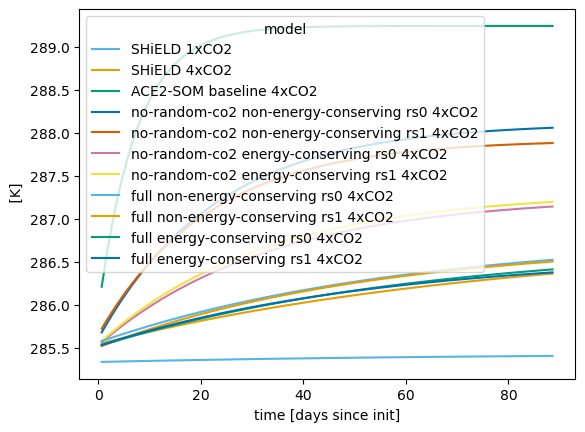

In [26]:
evaluate(ds_daily.air_temperature_7.curvefit("time", function_to_fit), ds_daily.time).plot(hue="model")

In [27]:
ds_daily.air_temperature_7.curvefit("time", function_to_fit).curvefit_coefficients.to_dataframe()

curvefit_coefficients
model                                         param                                   
SHiELD 1xCO2                                  initial_value                 285.338039
                                              equilibrium_value             285.439655
                                              timescale                      74.418516
SHiELD 4xCO2                                  initial_value                 285.545522
                                              equilibrium_value             286.767992
                                              timescale                      79.752824
ACE2-SOM baseline 4xCO2                       initial_value                 285.946568
                                              equilibrium_value             289.245652
                                              timescale                       7.428798
no-random-co2 non-energy-conserving rs0 4xCO2 initial_value                 285.614775
                                              equilibrium_value             288.115536
                                              timescale                      23.114573
no-random-co2 non-energy-conserving rs1 4xCO2 initial_value                 285.660550
                                              equilibrium_value             287.921989
                                              timescale                      21.715886
no-random-co2 energy-conserving rs0 4xCO2     initial_value                 285.535399
                                              equilibrium_value             287.268822
                                              timescale                      33.504841
no-random-co2 energy-conserving rs1 4xCO2     initial_value                 285.548543
                                              equilibrium_value             287.314947
                                              timescale                      32.444069
full non-energy-conserving rs0 4xCO2          initial_value                 285.567660
                                              equilibrium_value             286.806428
                                              timescale                      59.604623
full non-energy-conserving rs1 4xCO2          initial_value                 285.508421
                                              equilibrium_value             286.737269
                                              timescale                      53.090523
full energy-conserving rs0 4xCO2              initial_value                 285.520221
                                              equilibrium_value             286.704135
                                              timescale                      62.937549
full energy-conserving rs1 4xCO2              initial_value                 285.524561
                                              equilibrium_value             286.586363
                                              timescale                      54.130581

In [30]:
ds_daily_zeroed_time.air_temperature_7.curvefit("time", function_to_fit).curvefit_coefficients.to_dataframe()

curvefit_coefficients
model                                         param                                   
SHiELD 1xCO2                                  initial_value                 285.338890
                                              equilibrium_value             285.439659
                                              timescale                      74.423319
SHiELD 4xCO2                                  initial_value                 285.555065
                                              equilibrium_value             286.767995
                                              timescale                      79.753211
ACE2-SOM baseline 4xCO2                       initial_value                 286.212773
                                              equilibrium_value             289.245652
                                              timescale                       7.428804
no-random-co2 non-energy-conserving rs0 4xCO2 initial_value                 285.681486
                                              equilibrium_value             288.115534
                                              timescale                      23.114514
no-random-co2 non-energy-conserving rs1 4xCO2 initial_value                 285.724709
                                              equilibrium_value             287.921989
                                              timescale                      21.715921
no-random-co2 energy-conserving rs0 4xCO2     initial_value                 285.567435
                                              equilibrium_value             287.268821
                                              timescale                      33.504812
no-random-co2 energy-conserving rs1 4xCO2     initial_value                 285.582243
                                              equilibrium_value             287.314945
                                              timescale                      32.443950
full non-energy-conserving rs0 4xCO2          initial_value                 285.580582
                                              equilibrium_value             286.806429
                                              timescale                      59.604697
full non-energy-conserving rs1 4xCO2          initial_value                 285.522803
                                              equilibrium_value             286.737270
                                              timescale                      53.090579
full energy-conserving rs0 4xCO2              initial_value                 285.531920
                                              equilibrium_value             286.704135
                                              timescale                      62.937524
full energy-conserving rs1 4xCO2              initial_value                 285.536750
                                              equilibrium_value             286.586362
                                              timescale                      54.130388

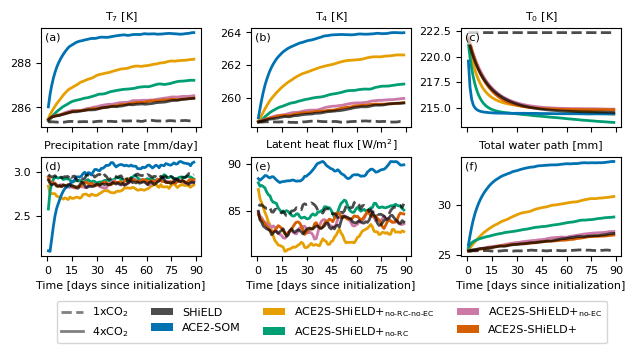

In [15]:
plotting.configure_style()

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = faceted.faceted(2, 3, width=6.5, sharey=False, internal_pad=(0.5, 0.3), left_pad=0.4, bottom_pad=0.9, right_pad=0.3, top_pad=0.25)
for model in ds_daily.model:
    ls = "-" if "4xCO2" in model.item() else "--"
    zorder = 0 if "SHiELD" not in model.item() else 10
    alpha = 1.0 if "SHiELD" not in model.item() else 0.7
    if "baseline" in model.item():
        zorder = 5
        lw = 2
    else:
        lw = 2
    ds_daily.sel(model=model).air_temperature_7.plot(ax=ax1, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).air_temperature_4.plot(ax=ax2, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).air_temperature_0.plot(ax=ax3, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)

    ds_daily.sel(model=model).PRATEsfc.plot(ax=ax4, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).LHTFLsfc.plot(ax=ax5, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).total_water_path.plot(ax=ax6, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)

ax1.set_title(textwrap.fill("T$_7$ [K]", width=30))
ax2.set_title(textwrap.fill("T$_4$ [K]", width=30))
ax3.set_title(textwrap.fill("T$_0$ [K]", width=30))

ax4.set_title(textwrap.fill("Precipitation rate [mm/day]", width=30))
ax5.set_title(textwrap.fill("Latent heat flux [W/m$^2$]", width=30))
ax6.set_title(textwrap.fill("Total water path [mm]", width=30))

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in (ax4, ax5, ax6):
    ax.set_xlabel("Time [days since initialization]")
    ax.set_ylabel("")
    ax.set_xticks(np.arange(0, 91, 15))

line_data = {
    "1xCO$_2$": ("gray", "--"),
    "4xCO$_2$": ("gray", "-"),
}
lines = [Line2D([0], [0], color=color, linestyle=ls, lw=2) for color, ls in line_data.values()]
patch_colors = {
    "SHiELD": ("k", 0.7),
    "ACE2-SOM": ("C3", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC-no-EC}}$": ("C1", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC}}$": ("C2", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-EC}}$": ("C5", 1.0),
    "ACE2S-SHiELD+": ("C4", 1.0),
}

from matplotlib.patches import Patch

patches = [
    Patch(facecolor=color, label=label, edgecolor='none', alpha=alpha)
    for label, (color, alpha) in patch_colors.items()
]

ax5.legend(lines + patches, list(line_data.keys()) + list(patch_colors.keys()), bbox_to_anchor=(-1.25, -0.4), bbox_transform=ax5.transAxes, loc="upper left", ncol=4, fontsize=8)

for ax, label in zip((ax1, ax2, ax3, ax4, ax5, ax6), ("a", "b", "c", "d", "e", "f")):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(3, -3),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        zorder=100,
    )

fig.patch.set_alpha(0.0)
fig.savefig("figure-08.png", dpi=300)
fig.savefig("figure-08.pdf")


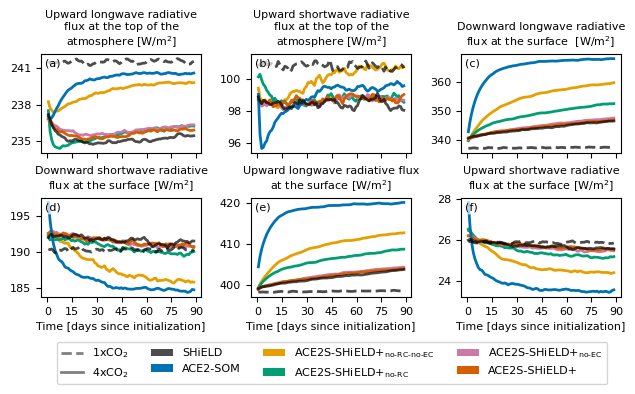

In [16]:
plotting.configure_style()

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = faceted.faceted(2, 3, width=6.5, sharey=False, internal_pad=(0.5, 0.45), left_pad=0.4, bottom_pad=0.9, right_pad=0.3, top_pad=0.5)
for model in ds_daily.model:
    ls = "-" if "4xCO2" in model.item() else "--"
    zorder = 0 if "SHiELD" not in model.item() else 10
    alpha = 1.0 if "SHiELD" not in model.item() else 0.7
    if "baseline" in model.item():
        zorder = 5
        lw = 2
    else:
        lw = 2
    ds_daily.sel(model=model).ULWRFtoa.plot(ax=ax1, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).USWRFtoa.plot(ax=ax2, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).DLWRFsfc.plot(ax=ax3, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).DSWRFsfc.plot(ax=ax4, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).ULWRFsfc.plot(ax=ax5, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)
    ds_daily.sel(model=model).USWRFsfc.plot(ax=ax6, color=COLORS[model.item()], ls=ls, lw=lw, zorder=zorder, alpha=alpha)

ax1.set_title(textwrap.fill("Upward longwave radiative flux at the top of the atmosphere [W/m$^2$]", width=29))
ax2.set_title(textwrap.fill("Upward shortwave radiative flux at the top of the atmosphere [W/m$^2$]", width=30))
ax3.set_title(textwrap.fill("Downward longwave radiative flux at the surface  [W/m$^2$]", width=30))

ax4.set_title(textwrap.fill("Downward shortwave radiative flux at the surface [W/m$^2$]", width=30))
ax5.set_title(textwrap.fill("Upward longwave radiative flux at the surface [W/m$^2$]", width=30))
ax6.set_title(textwrap.fill("Upward shortwave radiative flux at the surface [W/m$^2$]", width=30))

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in (ax4, ax5, ax6):
    ax.set_xlabel("Time [days since initialization]")
    ax.set_ylabel("")
    ax.set_xticks(np.arange(0, 91, 15))

line_data = {
    "1xCO$_2$": ("gray", "--"),
    "4xCO$_2$": ("gray", "-"),
}
lines = [Line2D([0], [0], color=color, linestyle=ls, lw=2) for color, ls in line_data.values()]
patch_colors = {
    "SHiELD": ("k", 0.7),
    "ACE2-SOM": ("C3", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC-no-EC}}$": ("C1", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC}}$": ("C2", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-EC}}$": ("C5", 1.0),
    "ACE2S-SHiELD+": ("C4", 1.0),
}

from matplotlib.patches import Patch

patches = [
    Patch(facecolor=color, label=label, edgecolor='none', alpha=alpha)
    for label, (color, alpha) in patch_colors.items()
]

ax5.legend(lines + patches, list(line_data.keys()) + list(patch_colors.keys()), bbox_to_anchor=(-1.25, -0.4), bbox_transform=ax5.transAxes, loc="upper left", ncol=4, fontsize=8)

for ax, label in zip((ax1, ax2, ax3, ax4, ax5, ax6), ("a", "b", "c", "d", "e", "f")):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(3, -3),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        zorder=100,
    )

ax1.set_yticks([235, 238, 241])

fig.patch.set_alpha(0.0)
fig.savefig("figure-10.png", dpi=300)
fig.savefig("figure-10.pdf")